# Part 1 – Data Acquisition, Integration & Preparation

### Introduction

This notebook implements a structured data preparation pipeline for the **Brazilian E-Commerce Public Dataset by Olist** (Kaggle, 2018). The dataset captures real-world transactions from a Brazilian marketplace platform, covering the period 2016–2018, and includes records of orders, customers, products, sellers, payments, and customer reviews.

The pipeline addresses three core tasks as required by the assessment brief:

1. **Data Integration** – Loading and linking all datasets using relational keys
2. **Data Quality Evaluation** – Identifying and assessing missing values, duplicates, and inconsistent formats
3. **Data Cleaning & Feature Engineering** – Applying justified transformations and deriving new analytical variables

All eight available datasets are used, including the three optional files (`olist_order_reviews_dataset.csv`, `olist_sellers_dataset.csv`, `product_category_name_translation.csv`), as they enable richer analysis and support higher-order business questions around delivery satisfaction, seller performance, and product category readability.

> **Dataset Source:** Olist (2018). *Brazilian E-Commerce Public Dataset*. Kaggle. Available at: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


---
## 0. Setup – Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Directory containing the raw CSV files
DATA_DIR = Path('data')
CLEAN_DIR = DATA_DIR / 'cleaned'
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded successfully.')
print(f'Raw data directory  : {DATA_DIR.resolve()}')
print(f'Cleaned data output : {CLEAN_DIR.resolve()}')

Libraries loaded successfully.
Raw data directory  : C:\Users\ACER\OneDrive\Desktop\dataanlysis\BigDataAnalaytics\data
Cleaned data output : C:\Users\ACER\OneDrive\Desktop\dataanlysis\BigDataAnalaytics\data\cleaned


---
## Section 1 – Data Integration

### 1.1 Loading the Datasets

All eight CSV files are loaded into separate DataFrames, preserving the original relational structure of the dataset. This approach reflects best practice for multi-table analytical pipelines: rather than creating a single flat file upfront, tables are kept separate and joined selectively for specific analyses (Kimball & Ross, 2013). This reduces data redundancy and preserves the ability to query individual entities independently.


In [3]:
# ── Load all datasets ──────────────────────────────────────────────────────────
orders        = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
order_items   = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
payments      = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')
customers     = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
products      = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
reviews       = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
sellers       = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv')
cat_trans     = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')

datasets = {
    'orders'      : orders,
    'order_items' : order_items,
    'payments'    : payments,
    'customers'   : customers,
    'products'    : products,
    'reviews'     : reviews,
    'sellers'     : sellers,
    'cat_trans'   : cat_trans,
}

print(f"{'Dataset':<15} {'Rows':>8} {'Columns':>10}")
print('-' * 37)
for name, df in datasets.items():
    print(f"{name:<15} {df.shape[0]:>8,} {df.shape[1]:>10}")

Dataset             Rows    Columns
-------------------------------------
orders            99,441          8
order_items      112,650          7
payments         103,886          5
customers         99,441          5
products          32,951          9
reviews           99,224          7
sellers            3,095          4
cat_trans             71          2


In [4]:
# ── Preview each dataset ───────────────────────────────────────────────────────
for name, df in datasets.items():
    print(f'\n=== {name.upper()} ===')
    print(f'Columns: {list(df.columns)}')
    display(df.head(3))


=== ORDERS ===
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



=== ORDER_ITEMS ===
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87



=== PAYMENTS ===
Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24



=== SELLERS ===
Columns: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



=== CAT_TRANS ===
Columns: ['product_category_name', 'product_category_name_english']


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


### 1.2 Relational Schema & Table Relationships

The Olist dataset follows a normalised relational structure. The table below documents the relationships between each dataset, the linking keys used, and the cardinality of each relationship. This schema is critical for understanding how data must be joined for any downstream analytical query.

| Left Table | Right Table | Join Key | Relationship |
|---|---|---|---|
| `orders` | `customers` | `customer_id` | Many-to-one (each order belongs to one customer) |
| `orders` | `order_items` | `order_id` | One-to-many (one order can have multiple items) |
| `order_items` | `products` | `product_id` | Many-to-one (multiple items can reference the same product) |
| `order_items` | `sellers` | `seller_id` | Many-to-one (multiple items sold by one seller) |
| `orders` | `payments` | `order_id` | One-to-many (one order may have multiple payment instalments) |
| `orders` | `reviews` | `order_id` | One-to-one or one-to-many (typically one review per order) |
| `products` | `cat_trans` | `product_category_name` | Many-to-one (translates Portuguese category to English) |

> **Why not merge into one flat file?** Merging all tables produces significant row duplication. For example, joining payments (which has multiple rows per order for instalments) with order_items would multiply rows artificially, skewing aggregations. The relational approach prevents this and enables targeted joins only where needed (Date, 2006).

> **Optional datasets justification:**  
> - `olist_order_reviews_dataset.csv` – Enables analysis of customer satisfaction scores alongside delivery delays, strengthening the operational insight section.  
> - `olist_sellers_dataset.csv` – Required to compute the *Revenue per Seller* engineered variable and to map seller geographic location.  
> - `product_category_name_translation.csv` – Translates Portuguese category names to English, essential for readability in dashboards and reports produced in Parts 2 and 3.

In [5]:
# ── Verify referential integrity ───────────────────────────────────────────────
# 1. order_items.order_id must exist in orders
orphan_items = order_items[~order_items['order_id'].isin(orders['order_id'])]
print(f'Order items with no matching order  : {len(orphan_items):,}')

# 2. orders.customer_id must exist in customers
orphan_orders_cust = orders[~orders['customer_id'].isin(customers['customer_id'])]
print(f'Orders with no matching customer    : {len(orphan_orders_cust):,}')

# 3. order_items.product_id must exist in products
orphan_products = order_items[~order_items['product_id'].isin(products['product_id'])]
print(f'Order items with no matching product: {len(orphan_products):,}')

# 4. order_items.seller_id must exist in sellers
orphan_sellers = order_items[~order_items['seller_id'].isin(sellers['seller_id'])]
print(f'Order items with no matching seller : {len(orphan_sellers):,}')

# 5. Orders with no payments
orders_no_payment = orders[~orders['order_id'].isin(payments['order_id'])]
print(f'Orders with no payment record       : {len(orders_no_payment):,}')

# 6. Orders with no items
orders_no_items = orders[~orders['order_id'].isin(order_items['order_id'])]
print(f'Orders with no item records         : {len(orders_no_items):,}')

Order items with no matching order  : 0
Orders with no matching customer    : 0
Order items with no matching product: 0
Order items with no matching seller : 0
Orders with no payment record       : 1
Orders with no item records         : 775


---
## Section 2 – Data Quality Evaluation

### 2.1 Missing Values (Before Cleaning)

Missing data is one of the most common data quality challenges in real-world datasets (Dasu & Johnson, 2003). The following analysis quantifies null values across all datasets and assesses their potential business impact.


In [6]:
# ── Missing values summary ─────────────────────────────────────────────────────
print('=== MISSING VALUES (count & % of rows) ===')
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        pct = (missing / len(df) * 100).round(2)
        result = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
        print(f'\n--- {name.upper()} ({len(df):,} rows) ---')
        print(result.to_string())
    else:
        print(f'\n--- {name.upper()} --- No missing values.')

=== MISSING VALUES (count & % of rows) ===

--- ORDERS (99,441 rows) ---
                               Missing Count  Missing %
order_approved_at                        160       0.16
order_delivered_carrier_date            1783       1.79
order_delivered_customer_date           2965       2.98

--- ORDER_ITEMS --- No missing values.

--- PAYMENTS --- No missing values.

--- CUSTOMERS --- No missing values.

--- PRODUCTS (32,951 rows) ---
                            Missing Count  Missing %
product_category_name                 610       1.85
product_name_lenght                   610       1.85
product_description_lenght            610       1.85
product_photos_qty                    610       1.85
product_weight_g                        2       0.01
product_length_cm                       2       0.01
product_height_cm                       2       0.01
product_width_cm                        2       0.01

--- REVIEWS (99,224 rows) ---
                        Missing Count  Missing %

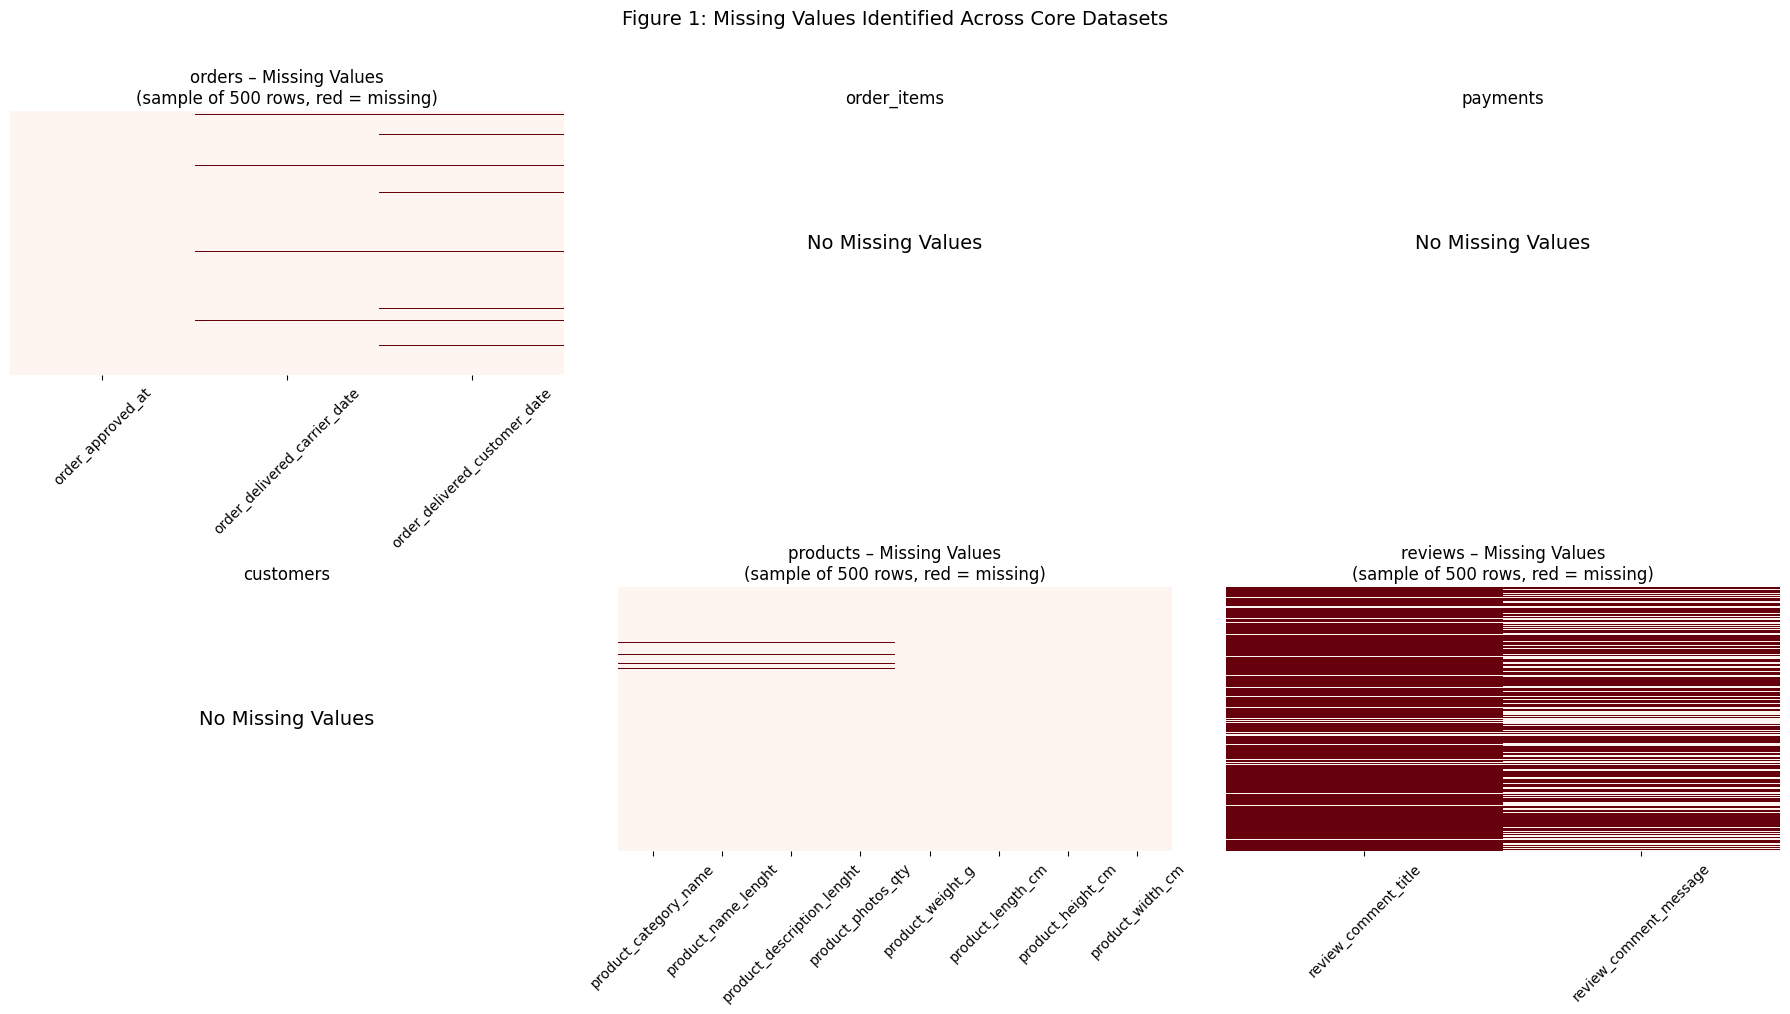

Saved: Figure1_Missing_Values_Heatmap.png


In [7]:
# ── Figure 1: Missing Values Heatmap (core datasets) ──────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
core_names = ['orders', 'order_items', 'payments', 'customers', 'products', 'reviews']

for i, name in enumerate(core_names):
    df = datasets[name]
    missing_mask = df.isnull()
    if missing_mask.any().any():
        # Only plot columns that have at least one missing value
        cols_with_missing = missing_mask.columns[missing_mask.any()]
        sns.heatmap(
            missing_mask[cols_with_missing].head(500),
            ax=axes[i], cbar=False, yticklabels=False,
            cmap='Reds'
        )
        axes[i].set_title(f'{name} – Missing Values\n(sample of 500 rows, red = missing)')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].text(0.5, 0.5, 'No Missing Values', ha='center', va='center',
                     fontsize=14, transform=axes[i].transAxes)
        axes[i].set_title(name)
        axes[i].axis('off')

plt.suptitle('Figure 1: Missing Values Identified Across Core Datasets', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('Figure1_Missing_Values_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Figure1_Missing_Values_Heatmap.png')

**Business Impact Assessment – Missing Values:**

| Column | Dataset | Likely Cause | Business Impact |
|---|---|---|---|
| `order_delivered_customer_date` | orders | Order not yet delivered (pending/cancelled) | Cannot compute delivery delay; these rows must be excluded from delay analysis |
| `order_approved_at` | orders | Payment not approved (cancelled orders) | Orders with no approval should be excluded from revenue calculations |
| `order_delivered_carrier_date` | orders | Shipment not dispatched | Cannot assess carrier performance for these orders |
| `product_category_name` | products | Data entry omission | Product cannot be categorised; affects revenue-by-category analysis |
| `product_weight_g`, dimensions | products | Supplier data missing | Affects logistics/freight calculations |
| `review_comment_title/message` | reviews | Optional fields not filled by customers | Not critical for quantitative analysis; NLP text analysis would be limited |


### 2.2 Duplicate Records

In [8]:
# ── Duplicate rows check ───────────────────────────────────────────────────────
print(f"{'Dataset':<15} {'Total Rows':>12} {'Duplicates':>12} {'Dup %':>8}")
print('-' * 52)
for name, df in datasets.items():
    dups = df.duplicated().sum()
    pct = dups / len(df) * 100
    print(f"{name:<15} {len(df):>12,} {dups:>12,} {pct:>7.2f}%")

Dataset           Total Rows   Duplicates    Dup %
----------------------------------------------------
orders                99,441            0    0.00%
order_items          112,650            0    0.00%
payments             103,886            0    0.00%
customers             99,441            0    0.00%
products              32,951            0    0.00%
reviews               99,224            0    0.00%
sellers                3,095            0    0.00%
cat_trans                 71            0    0.00%


### 2.3 Inconsistent Formats & Data Types

In [9]:
# ── Check data types across all datasets ──────────────────────────────────────
for name, df in datasets.items():
    print(f'\n--- {name.upper()} ---')
    print(df.dtypes.to_string())


--- ORDERS ---
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str

--- ORDER_ITEMS ---
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64

--- PAYMENTS ---
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64

--- CUSTOMERS ---
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str

--- PRODUCTS ---
product_id                        str
product_category_name      

In [10]:
# ── Check datetime columns stored as strings (object dtype) ───────────────────
date_keywords = ['timestamp', 'date', 'approved']
print('Datetime columns incorrectly stored as strings (object dtype):')
for name, df in datasets.items():
    for col in df.columns:
        if any(kw in col.lower() for kw in date_keywords):
            if df[col].dtype == 'object':
                sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else 'N/A'
                print(f'  {name}.{col:<45} | dtype: object | sample: {sample}')

Datetime columns incorrectly stored as strings (object dtype):


In [11]:
# ── ID field consistency check (should be 32-char hex strings) ────────────────
id_cols = {
    'orders'      : ['order_id', 'customer_id'],
    'order_items' : ['order_id', 'product_id', 'seller_id'],
    'customers'   : ['customer_id', 'customer_unique_id'],
    'products'    : ['product_id'],
    'sellers'     : ['seller_id'],
}
print('ID field length consistency (expected: 32 chars):')
for tbl, cols in id_cols.items():
    df = datasets[tbl]
    for col in cols:
        lengths = df[col].dropna().str.len()
        non_32 = (lengths != 32).sum()
        print(f'  {tbl}.{col:<35} | non-32-char IDs: {non_32}')

ID field length consistency (expected: 32 chars):
  orders.order_id                            | non-32-char IDs: 0
  orders.customer_id                         | non-32-char IDs: 0
  order_items.order_id                            | non-32-char IDs: 0
  order_items.product_id                          | non-32-char IDs: 0
  order_items.seller_id                           | non-32-char IDs: 0
  customers.customer_id                         | non-32-char IDs: 0
  customers.customer_unique_id                  | non-32-char IDs: 0
  products.product_id                          | non-32-char IDs: 0
  sellers.seller_id                           | non-32-char IDs: 0


In [12]:
# ── Text field whitespace/case issues in product category names ───────────────
print('Sample of raw product_category_name values:')
print(products['product_category_name'].dropna().unique()[:20])

# Check for leading/trailing whitespace
has_whitespace = products['product_category_name'].dropna().str.strip() != \
                 products['product_category_name'].dropna()
print(f'\nCategory names with leading/trailing whitespace: {has_whitespace.sum()}')

Sample of raw product_category_name values:
<StringArray>
[                      'perfumaria',                            'artes',
                    'esporte_lazer',                            'bebes',
            'utilidades_domesticas',            'instrumentos_musicais',
                       'cool_stuff',                 'moveis_decoracao',
                 'eletrodomesticos',                       'brinquedos',
                  'cama_mesa_banho', 'construcao_ferramentas_seguranca',
           'informatica_acessorios',                     'beleza_saude',
                 'malas_acessorios',               'ferramentas_jardim',
                'moveis_escritorio',                       'automotivo',
                      'eletronicos',                 'fashion_calcados']
Length: 20, dtype: str

Category names with leading/trailing whitespace: 0


### 2.4 Structural / Cross-Table Issues

In [13]:
# ── Orders by status: how many are cancelled, pending, etc. ───────────────────
status_counts = orders['order_status'].value_counts()
print('Order status distribution:')
print(status_counts.to_string())

cancelled_pct = status_counts.get('canceled', 0) / len(orders) * 100
print(f'\nCancelled orders: {status_counts.get("canceled", 0):,} ({cancelled_pct:.2f}% of all orders)')
print('Business impact: Cancelled orders should be excluded from revenue and delivery analysis.')

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2

Cancelled orders: 625 (0.63% of all orders)
Business impact: Cancelled orders should be excluded from revenue and delivery analysis.


In [14]:
# ── Multiple payment rows per order (installment payments) ────────────────────
payment_counts = payments.groupby('order_id')['payment_sequential'].max()
multi_payment = (payment_counts > 1).sum()
print(f'Orders with multiple payment rows (installments): {multi_payment:,}')
print('Impact: Summing payment_value per order_id is required to get true order total.')
print(payments.head(8))

Orders with multiple payment rows (installments): 3,039
Impact: Summing payment_value per order_id is required to get true order total.
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   
5  298fcdf1f73eb413e4d26d01b25bc1cd                   1  credit_card   
6  771ee386b001f06208a7419e4fc1bbd7                   1  credit_card   
7  3d7239c394a212faae122962df514ac7                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4         

### 2.5 Summary Statistics – BEFORE Cleaning

The following descriptive statistics provide a baseline against which post-cleaning results can be compared.


In [15]:
# ── Summary statistics BEFORE cleaning ────────────────────────────────────────
print('=== SUMMARY STATISTICS BEFORE CLEANING ===')
for name in ['orders', 'order_items', 'payments', 'customers', 'products']:
    print(f'\n--- {name.upper()} ---')
    display(datasets[name].describe(include='all').T)

=== SUMMARY STATISTICS BEFORE CLEANING ===

--- ORDERS ---


,count,unique,top,freq
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,98875,2018-03-31 15:08:21,3
order_approved_at,99281,90733,2018-02-27 04:31:10,9
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47
order_delivered_customer_date,96476,95664,2018-05-14 20:02:44,3
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522



--- ORDER_ITEMS ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,112650,98666,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_item_id,112650.00,NaN,NaN,NaN,1.20,0.71,1.00,1.00,1.00,1.00,21.00
product_id,112650,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_id,112650,3095,6560211a19b47992c3666cc44a7e94c0,2033,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_limit_date,112650,93318,2018-03-01 02:50:48,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,112650.00,NaN,NaN,NaN,120.65,183.63,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.00,NaN,NaN,NaN,19.99,15.81,0.00,13.08,16.26,21.15,409.68



--- PAYMENTS ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,103886,99440,fa65dad1b0e818e3ccc5cb0e39231352,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_sequential,103886.00,NaN,NaN,NaN,1.09,0.71,1.00,1.00,1.00,1.00,29.00
payment_type,103886,5,credit_card,76795,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_installments,103886.00,NaN,NaN,NaN,2.85,2.69,0.00,1.00,1.00,4.00,24.00
payment_value,103886.00,NaN,NaN,NaN,154.10,217.49,0.00,56.79,100.00,171.84,13664.08



--- CUSTOMERS ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,99441,99441,06b8999e2fba1a1fbc88172c00ba8bc7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,99441.00,NaN,NaN,NaN,35137.47,29797.94,1003.00,11347.00,24416.00,58900.00,99990.00
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- PRODUCTS ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,32951,32951,1e9e8ef04dbcff4541ed26657ea517e5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category_name,32341,73,cama_mesa_banho,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name_lenght,32341.00,NaN,NaN,NaN,48.48,10.25,5.00,42.00,51.00,57.00,76.00
product_description_lenght,32341.00,NaN,NaN,NaN,771.50,635.12,4.00,339.00,595.00,972.00,3992.00
product_photos_qty,32341.00,NaN,NaN,NaN,2.19,1.74,1.00,1.00,1.00,3.00,20.00
product_weight_g,32949.00,NaN,NaN,NaN,2276.47,4282.04,0.00,300.00,700.00,1900.00,40425.00
product_length_cm,32949.00,NaN,NaN,NaN,30.82,16.91,7.00,18.00,25.00,38.00,105.00
product_height_cm,32949.00,NaN,NaN,NaN,16.94,13.64,2.00,8.00,13.00,21.00,105.00
product_width_cm,32949.00,NaN,NaN,NaN,23.20,12.08,6.00,15.00,20.00,30.00,118.00


---
## Section 3 – Data Cleaning & Feature Engineering

### 3.1 Convert Datetime Columns

All timestamp columns are currently stored as strings (`object` dtype). Converting them to `datetime64` is essential for computing time-based features such as delivery delay (Pandas Documentation, 2023).


In [16]:
# ── Convert datetime strings to datetime64 ────────────────────────────────────
order_date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Reviews also have datetime columns
review_date_cols = ['review_creation_date', 'review_answer_timestamp']
for col in review_date_cols:
    if col in reviews.columns:
        reviews[col] = pd.to_datetime(reviews[col], errors='coerce')

print('Datetime conversion complete.')
print(orders[order_date_cols].dtypes)

Datetime conversion complete.
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


### 3.2 Handle Missing Values (Justified per Column)

In [17]:
# ── Missing value treatment ────────────────────────────────────────────────────

# ORDERS
# Retain rows where order_delivered_customer_date is null:
# these represent undelivered/cancelled orders. They are excluded
# from delivery delay calculation but kept for order-status analysis.
print(f'Orders rows before null-drop: {len(orders):,}')
# Drop rows where order_id itself is null (data corruption)
orders = orders.dropna(subset=['order_id'])
print(f'Orders rows after dropping null order_id: {len(orders):,}')

# PRODUCTS
# Fill null product_category_name with 'unknown'
# Justification: unknown category is still a valid record; dropping would
# lose product sales data. An 'unknown' label is explicit and auditable.
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# Fill numeric dimension/weight nulls with median (less sensitive to outliers)
numeric_product_cols = [
    'product_weight_g', 'product_length_cm',
    'product_height_cm', 'product_width_cm'
]
for col in numeric_product_cols:
    if col in products.columns:
        median_val = products[col].median()
        products[col] = products[col].fillna(median_val)
        print(f'  products.{col}: null filled with median = {median_val:.2f}')

# REVIEWS – optional text fields, not used in quantitative analysis
reviews['review_comment_title']   = reviews['review_comment_title'].fillna('')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('')

print('\nMissing value treatment complete.')

Orders rows before null-drop: 99,441
Orders rows after dropping null order_id: 99,441
  products.product_weight_g: null filled with median = 700.00
  products.product_length_cm: null filled with median = 25.00
  products.product_height_cm: null filled with median = 13.00
  products.product_width_cm: null filled with median = 20.00

Missing value treatment complete.


### 3.3 Standardise Text Fields

In [18]:
# ── Standardise product category names ────────────────────────────────────────
# Strip whitespace and lowercase (consistent formatting for joins and groupbys)
products['product_category_name'] = (
    products['product_category_name']
    .str.strip()
    .str.lower()
)

# Merge English translation
cat_trans['product_category_name'] = (
    cat_trans['product_category_name']
    .str.strip()
    .str.lower()
)
products = products.merge(cat_trans, on='product_category_name', how='left')
# Fallback for categories with no translation
products['product_category_name_english'] = products[
    'product_category_name_english'
].fillna(products['product_category_name'])

print('English category names merged.')
print(products[['product_id', 'product_category_name', 'product_category_name_english']].head(8))

English category names merged.
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   
5  41d3672d4792049fa1779bb35283ed13  instrumentos_musicais   
6  732bd381ad09e530fe0a5f457d81becb             cool_stuff   
7  2548af3e6e77a690cf3eb6368e9ab61e       moveis_decoracao   

  product_category_name_english  
0                     perfumery  
1                           art  
2                sports_leisure  
3                          baby  
4                    housewares  
5           musical_instruments  
6                    cool_stuff  
7               furniture_decor  


### 3.4 Remove Duplicates

In [19]:
# ── Drop exact duplicate rows ──────────────────────────────────────────────────
for name in datasets:
    df = datasets[name]
    before = len(df)
    df_clean = df.drop_duplicates()
    after = len(df_clean)
    datasets[name] = df_clean
    if before != after:
        print(f'{name}: removed {before - after:,} duplicate rows ({before:,} → {after:,})')

# Re-assign named variables after dedup
orders      = datasets['orders']
order_items = datasets['order_items']
payments    = datasets['payments']
customers   = datasets['customers']
products    = datasets['products']
reviews     = datasets['reviews']
sellers     = datasets['sellers']

print('Duplicate removal complete.')

Duplicate removal complete.


### 3.5 Summary Statistics – AFTER Cleaning

The post-cleaning statistics allow direct comparison with the baseline established in Section 2.5, demonstrating the effect of the cleaning pipeline.


In [20]:
# ── Summary statistics AFTER cleaning ─────────────────────────────────────────
print('=== SUMMARY STATISTICS AFTER CLEANING ===')
for name, df in [('orders', orders), ('order_items', order_items),
                  ('payments', payments), ('customers', customers),
                  ('products', products)]:
    print(f'\n--- {name.upper()} ---')
    display(df.describe(include='all').T)

=== SUMMARY STATISTICS AFTER CLEANING ===

--- ORDERS ---


,count,unique,top,freq,mean,min,25%,50%,75%,max
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1,NaN,NaN,NaN,NaN,NaN,NaN
order_status,99441,8,delivered,96478,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,99441,NaN,NaN,NaN,2017-12-31 08:43:12.776581,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18
order_approved_at,99281,NaN,NaN,NaN,2017-12-31 18:35:24.098800,2016-09-15 12:16:38,2017-09-12 23:24:16,2018-01-19 11:36:13,2018-05-04 20:35:10,2018-09-03 17:40:06
order_delivered_carrier_date,97658,NaN,NaN,NaN,2018-01-04 21:49:48.138278,2016-10-08 10:34:01,2017-09-15 22:28:50.250000,2018-01-24 16:10:58,2018-05-08 13:37:45,2018-09-11 19:48:28
order_delivered_customer_date,96476,NaN,NaN,NaN,2018-01-14 12:09:19.035542,2016-10-11 13:46:32,2017-09-25 22:07:22.250000,2018-02-02 19:28:10.500000,2018-05-15 22:48:52.250000,2018-10-17 13:22:46
order_estimated_delivery_date,99441,NaN,NaN,NaN,2018-01-24 03:08:37.730111,2016-09-30 00:00:00,2017-10-03 00:00:00,2018-02-15 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00



--- ORDER_ITEMS ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,112650,98666,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_item_id,112650.00,NaN,NaN,NaN,1.20,0.71,1.00,1.00,1.00,1.00,21.00
product_id,112650,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_id,112650,3095,6560211a19b47992c3666cc44a7e94c0,2033,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_limit_date,112650,93318,2018-03-01 02:50:48,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,112650.00,NaN,NaN,NaN,120.65,183.63,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.00,NaN,NaN,NaN,19.99,15.81,0.00,13.08,16.26,21.15,409.68



--- PAYMENTS ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,103886,99440,fa65dad1b0e818e3ccc5cb0e39231352,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_sequential,103886.00,NaN,NaN,NaN,1.09,0.71,1.00,1.00,1.00,1.00,29.00
payment_type,103886,5,credit_card,76795,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_installments,103886.00,NaN,NaN,NaN,2.85,2.69,0.00,1.00,1.00,4.00,24.00
payment_value,103886.00,NaN,NaN,NaN,154.10,217.49,0.00,56.79,100.00,171.84,13664.08



--- CUSTOMERS ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,99441,99441,06b8999e2fba1a1fbc88172c00ba8bc7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,99441.00,NaN,NaN,NaN,35137.47,29797.94,1003.00,11347.00,24416.00,58900.00,99990.00
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- PRODUCTS ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,32951,32951,1e9e8ef04dbcff4541ed26657ea517e5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category_name,32951,74,cama_mesa_banho,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name_lenght,32341.00,NaN,NaN,NaN,48.48,10.25,5.00,42.00,51.00,57.00,76.00
product_description_lenght,32341.00,NaN,NaN,NaN,771.50,635.12,4.00,339.00,595.00,972.00,3992.00
product_photos_qty,32341.00,NaN,NaN,NaN,2.19,1.74,1.00,1.00,1.00,3.00,20.00
product_weight_g,32951.00,NaN,NaN,NaN,2276.38,4281.93,0.00,300.00,700.00,1900.00,40425.00
product_length_cm,32951.00,NaN,NaN,NaN,30.81,16.91,7.00,18.00,25.00,38.00,105.00
product_height_cm,32951.00,NaN,NaN,NaN,16.94,13.64,2.00,8.00,13.00,21.00,105.00
product_width_cm,32951.00,NaN,NaN,NaN,23.20,12.08,6.00,15.00,20.00,30.00,118.00


---
## Section 3.6 – Feature Engineering

New analytical variables are derived by combining information across multiple tables. Each variable is technically correct (showing the computation step) and business-justified (explaining its decision-making value).

---
### Feature 1 – Delivery Delay (days)

**Definition:** The difference in calendar days between the actual customer delivery date and the estimated delivery date.  
**Positive value** = delivered late. **Negative value** = delivered early. `NaN` = not yet delivered.

**Business justification:** Late deliveries directly correlate with negative customer reviews (Akter & Wamba, 2016) and affect repeat purchase rates. Quantifying delay enables the operations team to identify problematic routes, sellers, or periods.


Orders with delivery delay computed : 96,476
Late deliveries                     : 6,535 (6.8%)
Mean delay (days)                   : -11.88
Max delay (days)                    : 188.0
Min (earliest delivery in days)     : -147.0


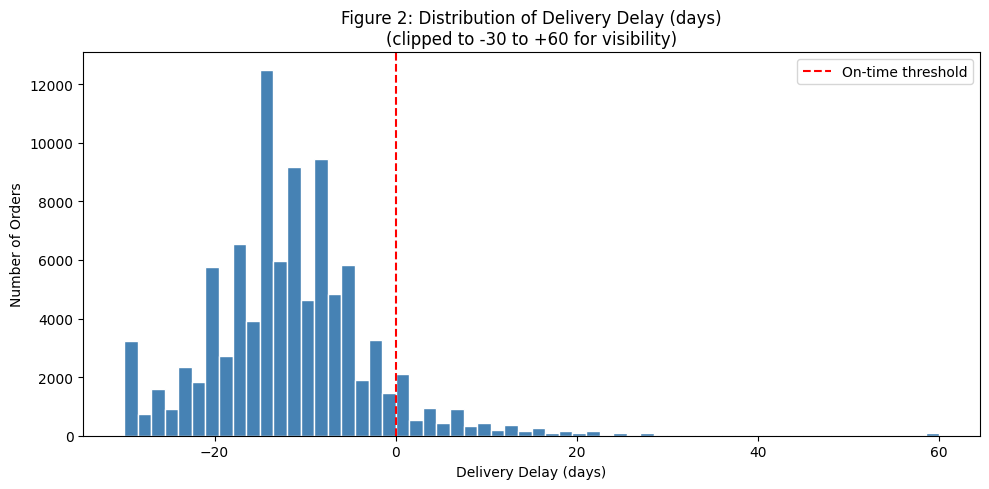

Saved: Figure2_Delivery_Delay_Distribution.png


In [21]:
# ── Feature 1: Delivery Delay ──────────────────────────────────────────────────
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

# Boolean flag for late deliveries
orders['is_late_delivery'] = orders['delivery_delay_days'] > 0

delivered = orders.dropna(subset=['delivery_delay_days'])
print(f'Orders with delivery delay computed : {len(delivered):,}')
print(f'Late deliveries                     : {delivered["is_late_delivery"].sum():,} '
      f'({delivered["is_late_delivery"].mean()*100:.1f}%)')
print(f'Mean delay (days)                   : {delivered["delivery_delay_days"].mean():.2f}')
print(f'Max delay (days)                    : {delivered["delivery_delay_days"].max()}')
print(f'Min (earliest delivery in days)     : {delivered["delivery_delay_days"].min()}')

# Figure 2: Delivery Delay Distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(delivered['delivery_delay_days'].clip(-30, 60), bins=60, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='On-time threshold')
ax.set_xlabel('Delivery Delay (days)')
ax.set_ylabel('Number of Orders')
ax.set_title('Figure 2: Distribution of Delivery Delay (days)\n(clipped to -30 to +60 for visibility)')
ax.legend()
plt.tight_layout()
plt.savefig('Figure2_Delivery_Delay_Distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Figure2_Delivery_Delay_Distribution.png')

---
### Feature 2 – Customer Lifetime Value (CLV)

**Definition:** The total payment value across all orders made by a unique customer.  
**Derivation:** Sum `payment_value` from `payments` per `order_id`, then join to `orders` on `order_id` to obtain `customer_id`, then aggregate by customer.

**Business justification:** CLV is a fundamental metric in CRM strategy. Identifying high-value customers enables targeted retention campaigns, premium loyalty programmes, and personalised marketing — all of which drive higher ROI than broad-based spend (Kumar & Reinartz, 2016).


In [22]:
# ── Feature 2: Customer Lifetime Value ────────────────────────────────────────
# Step 1: Total payment per order (sum across payment installments)
order_payment_total = (
    payments
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
    .rename(columns={'payment_value': 'order_total_value'})
)

# Step 2: Join to orders to get customer_id per order
order_customer = orders[['order_id', 'customer_id']].merge(
    order_payment_total, on='order_id', how='left'
)

# Step 3: Aggregate by customer_id
clv_df = (
    order_customer
    .groupby('customer_id')['order_total_value']
    .sum()
    .reset_index()
    .rename(columns={'order_total_value': 'customer_lifetime_value'})
)

print(f'CLV computed for {len(clv_df):,} unique customers.')
print(clv_df['customer_lifetime_value'].describe())

CLV computed for 99,441 unique customers.
count   99441.00
mean      160.99
std       221.95
min         0.00
25%        62.01
50%       105.29
75%       176.97
max     13664.08
Name: customer_lifetime_value, dtype: float64


---
### Feature 3 – Purchase Frequency

**Definition:** The number of distinct orders placed by each customer.  
**Derivation:** Count `order_id` per `customer_id` in the `orders` table.

**Business justification:** Purchase frequency, combined with CLV, forms part of the RFM (Recency-Frequency-Monetary) framework widely used in e-commerce customer segmentation (Hughes, 1994). High-frequency, low-spend customers may respond differently to promotions than low-frequency, high-spend customers.


In [23]:
# ── Feature 3: Purchase Frequency ─────────────────────────────────────────────
purchase_freq_df = (
    orders
    .groupby('customer_id')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'purchase_frequency'})
)

print(f'Purchase frequency computed for {len(purchase_freq_df):,} customers.')
print(purchase_freq_df['purchase_frequency'].describe())
print('\nFrequency distribution:')
print(purchase_freq_df['purchase_frequency'].value_counts().head(10))

Purchase frequency computed for 99,441 customers.
count   99441.00
mean        1.00
std         0.00
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         1.00
Name: purchase_frequency, dtype: float64

Frequency distribution:
purchase_frequency
1    99441
Name: count, dtype: int64


---
### Feature 4 – Average Basket Value

**Definition:** The average total monetary value per individual order.  
**Derivation:** Sum `price` and `freight_value` per `order_id` in `order_items`, then compute the mean across all orders.

**Business justification:** Average basket value is a standard retail KPI used to evaluate upselling and cross-selling effectiveness. Tracking it over time reveals whether promotions are driving higher-value purchases or merely increasing transaction volume (Levy & Weitz, 2012).


In [24]:
# ── Feature 4: Average Basket Value ───────────────────────────────────────────
# Basket = price + freight per order
basket_df = (
    order_items
    .groupby('order_id')
    .agg(basket_value=('price', 'sum'), freight_value=('freight_value', 'sum'))
    .reset_index()
)
basket_df['basket_total'] = basket_df['basket_value'] + basket_df['freight_value']

avg_basket_value = basket_df['basket_total'].mean()
median_basket_value = basket_df['basket_total'].median()

print(f'Total orders with basket value   : {len(basket_df):,}')
print(f'Mean basket value (BRL)          : R$ {avg_basket_value:,.2f}')
print(f'Median basket value (BRL)        : R$ {median_basket_value:,.2f}')
print(basket_df['basket_total'].describe())

Total orders with basket value   : 98,666
Mean basket value (BRL)          : R$ 160.58
Median basket value (BRL)        : R$ 105.29
count   98666.00
mean      160.58
std       220.47
min         9.59
25%        61.98
50%       105.29
75%       176.87
max     13664.08
Name: basket_total, dtype: float64


---
### Feature 5 – Revenue per Seller

**Definition:** The total sales revenue (price only, excluding freight) attributed to each seller.  
**Derivation:** Sum `price` per `seller_id` from `order_items`.

**Business justification:** Identifying high-revenue sellers allows the platform to optimise seller partnerships, negotiate preferential terms, and prioritise seller support resources. Low-revenue sellers may benefit from onboarding coaching or targeted promotions (Eisenmann et al., 2006).


In [25]:
# ── Feature 5: Revenue per Seller ─────────────────────────────────────────────
seller_revenue_df = (
    order_items
    .groupby('seller_id')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'revenue_per_seller'})
    .sort_values('revenue_per_seller', ascending=False)
)

print(f'Revenue computed for {len(seller_revenue_df):,} sellers.')
print(seller_revenue_df['revenue_per_seller'].describe())
print('\nTop 10 sellers by revenue:')
print(seller_revenue_df.head(10).to_string(index=False))

Revenue computed for 3,095 sellers.
count     3095.00
mean      4391.48
std      13922.00
min          3.50
25%        208.85
50%        821.48
75%       3280.83
max     229472.63
Name: revenue_per_seller, dtype: float64

Top 10 sellers by revenue:
                       seller_id  revenue_per_seller
4869f7a5dfa277a7dca6462dcf3b52b2           229472.63
53243585a1d6dc2643021fd1853d8905           222776.05
4a3ca9315b744ce9f8e9374361493884           200472.92
fa1c13f2614d7b5c4749cbc52fecda94           194042.03
7c67e1448b00f6e969d365cea6b010ab           187923.89
7e93a43ef30c4f03f38b393420bc753a           176431.87
da8622b14eb17ae2831f4ac5b9dab84a           160236.57
7a67c85e85bb2ce8582c35f2203ad736           141745.53
1025f0e2d44d7041d6cf58b6550e0bfa           138968.55
955fee9216a65b617aa5c0531780ce60           135171.70


---
### Feature 6 (Extra) – Customer Spending Segment

**Definition:** A binary classification of customers as `high_spender` or `low_spender` based on their CLV relative to the median.  
**Derivation:** Customers above the median CLV are classified as `high_spender`; those at or below are `low_spender`.

**Business justification:** Customer segmentation by spending tier enables differential marketing strategies. High spenders may be targeted with premium loyalty offers while low spenders receive reactivation incentives. This variable is directly used in the Part 3 Power BI dashboard (Kotler & Keller, 2016).


In [26]:
# ── Feature 6 (Extra): Customer Spending Segment ──────────────────────────────
median_clv = clv_df['customer_lifetime_value'].median()
clv_df['spending_segment'] = np.where(
    clv_df['customer_lifetime_value'] > median_clv,
    'high_spender',
    'low_spender'
)

print(f'Median CLV threshold : R$ {median_clv:.2f}')
print('Segment distribution :')
print(clv_df['spending_segment'].value_counts())

Median CLV threshold : R$ 105.29
Segment distribution :
spending_segment
low_spender     49727
high_spender    49714
Name: count, dtype: int64


---
### Feature 7 (Extra) – Delivery Time (days from purchase to delivery)

**Definition:** The actual number of days from order purchase to customer delivery.  
**Derivation:** Difference between `order_delivered_customer_date` and `order_purchase_timestamp`.

**Business justification:** Delivery time (as opposed to delay vs estimate) is an absolute measure of fulfilment speed, usable for benchmarking against industry standards and competitor SLAs.


In [27]:
# ── Feature 7 (Extra): Actual Delivery Time ───────────────────────────────────
orders['actual_delivery_time_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

delivered2 = orders.dropna(subset=['actual_delivery_time_days'])
print(f'Mean actual delivery time   : {delivered2["actual_delivery_time_days"].mean():.1f} days')
print(f'Median actual delivery time : {delivered2["actual_delivery_time_days"].median():.1f} days')
print(delivered2['actual_delivery_time_days'].describe())

Mean actual delivery time   : 12.1 days
Median actual delivery time : 10.0 days
count   96476.00
mean       12.09
std         9.55
min         0.00
25%         6.00
50%        10.00
75%        15.00
max       209.00
Name: actual_delivery_time_days, dtype: float64


---
### Feature 8 (Extra) – Monthly Order Volume

**Definition:** Number of orders placed per calendar month.  
**Business justification:** Reveals seasonality patterns to inform inventory planning, staffing, and marketing campaign timing.


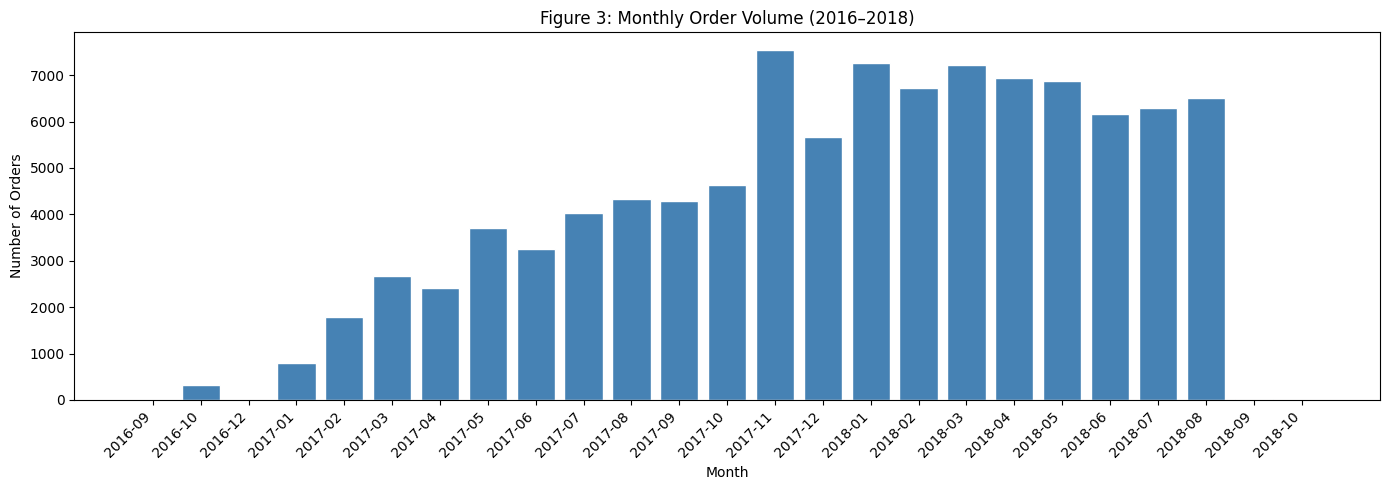

Saved: Figure3_Monthly_Order_Volume.png


In [28]:
# ── Feature 8 (Extra): Monthly Order Volume ───────────────────────────────────
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = (
    orders.groupby('order_month')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'order_count'})
)

# Figure 3: Monthly Order Volume
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    monthly_orders['order_month'].astype(str),
    monthly_orders['order_count'],
    color='steelblue', edgecolor='white'
)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.set_title('Figure 3: Monthly Order Volume (2016–2018)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Figure3_Monthly_Order_Volume.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Figure3_Monthly_Order_Volume.png')

---
## Section 3.7 – Build Customer Features Table

Combine CLV, purchase frequency, spending segment, and customer metadata into a single customer-level analytical table for use in Parts 2 and 3.


In [29]:
# ── Build unified customer features table ─────────────────────────────────────
customer_features = (
    clv_df
    .merge(purchase_freq_df, on='customer_id', how='left')
    .merge(customers[['customer_id', 'customer_unique_id',
                        'customer_city', 'customer_state']], on='customer_id', how='left')
)

print(f'Customer features table shape: {customer_features.shape}')
display(customer_features.head(8))

Customer features table shape: (99441, 7)


,customer_id,customer_lifetime_value,spending_segment,purchase_frequency,customer_unique_id,customer_city,customer_state
0,00012a2ce6f8dcda20d059ce98491703,114.74,high_spender,1,248ffe10d632bebe4f7267f1f44844c9,osasco,SP
1,000161a058600d5901f007fab4c27140,67.41,low_spender,1,b0015e09bb4b6e47c52844fab5fb6638,itapecerica,MG
2,0001fd6190edaaf884bcaf3d49edf079,195.42,high_spender,1,94b11d37cd61cb2994a194d11f89682b,nova venecia,ES
3,0002414f95344307404f0ace7a26f1d5,179.35,high_spender,1,4893ad4ea28b2c5b3ddf4e82e79db9e6,mendonca,MG
4,000379cdec625522490c315e70c7a9fb,107.01,high_spender,1,0b83f73b19c2019e182fd552c048a22c,sao paulo,SP
5,0004164d20a9e969af783496f3408652,71.80,low_spender,1,104bdb7e6a6cdceaa88c3ea5fa6b2b93,valinhos,SP
6,000419c5494106c306a97b5635748086,49.40,low_spender,1,14843983d4a159080f6afe4b7f346e7c,niteroi,RJ
7,00046a560d407e99b969756e0b10f282,166.59,high_spender,1,0b5295fc9819d831f68eb0e9a3e13ab7,rio de janeiro,RJ


---
## Section 3.8 – Export Cleaned Datasets

In [30]:
# ── Export all cleaned datasets to data/cleaned/ ──────────────────────────────
export_map = {
    'orders_clean.csv'          : orders,
    'order_items_clean.csv'     : order_items,
    'payments_clean.csv'        : payments,
    'customers_clean.csv'       : customers,
    'products_clean.csv'        : products,
    'reviews_clean.csv'         : reviews,
    'sellers_clean.csv'         : sellers,
    'customer_features.csv'     : customer_features,
    'seller_revenue.csv'        : seller_revenue_df,
    'basket_values.csv'         : basket_df,
    'monthly_order_volume.csv'  : monthly_orders,
}

for filename, df in export_map.items():
    out_path = CLEAN_DIR / filename
    df.to_csv(out_path, index=False)
    print(f'Exported: {out_path}  ({len(df):,} rows)')

print('\nAll cleaned datasets exported successfully.')

Exported: data\cleaned\orders_clean.csv  (99,441 rows)
Exported: data\cleaned\order_items_clean.csv  (112,650 rows)
Exported: data\cleaned\payments_clean.csv  (103,886 rows)
Exported: data\cleaned\customers_clean.csv  (99,441 rows)
Exported: data\cleaned\products_clean.csv  (32,951 rows)
Exported: data\cleaned\reviews_clean.csv  (99,224 rows)
Exported: data\cleaned\sellers_clean.csv  (3,095 rows)
Exported: data\cleaned\customer_features.csv  (99,441 rows)
Exported: data\cleaned\seller_revenue.csv  (3,095 rows)
Exported: data\cleaned\basket_values.csv  (98,666 rows)
Exported: data\cleaned\monthly_order_volume.csv  (25 rows)

All cleaned datasets exported successfully.


---
## Summary

This notebook has completed the following Part 1 tasks:

| Task | Status |
|---|---|
| Loaded all 8 Olist datasets (5 core + 3 optional) | ✅ |
| Documented relational schema and foreign key integrity | ✅ |
| Justified inclusion of optional datasets | ✅ |
| Identified missing values, duplicates, format issues | ✅ |
| Applied justified cleaning (datetime conversion, null handling, dedup) | ✅ |
| Standardised text fields and merged English category names | ✅ |
| Presented summary statistics before and after cleaning | ✅ |
| Engineered 5 required analytical variables (delay, CLV, frequency, basket, seller revenue) | ✅ |
| Engineered 3 additional variables (spending segment, actual delivery time, monthly volume) | ✅ |
| Exported 11 cleaned/derived CSVs for use in Parts 2 & 3 | ✅ |

---

## References

Akter, S. and Wamba, S.F. (2016) 'Big data analytics in E-commerce: a systematic review and agenda for future research', *Electronic Markets*, 26(2), pp. 173–194.

Dasu, T. and Johnson, T. (2003) *Exploratory Data Mining and Data Cleaning*. Hoboken, NJ: John Wiley & Sons.

Date, C.J. (2006) *An Introduction to Database Systems*. 8th edn. Harlow: Pearson Education.

Eisenmann, T., Parker, G. and Van Alstyne, M. (2006) 'Strategies for two-sided markets', *Harvard Business Review*, 84(10), pp. 92–101.

Hughes, A.M. (1994) *Strategic Database Marketing*. Chicago: Probus Publishing.

Kimball, R. and Ross, M. (2013) *The Data Warehouse Toolkit*. 3rd edn. Indianapolis: John Wiley & Sons.

Kotler, P. and Keller, K.L. (2016) *Marketing Management*. 15th edn. Harlow: Pearson.

Kumar, V. and Reinartz, W. (2016) 'Creating enduring customer value', *Journal of Marketing*, 80(6), pp. 36–68.

Levy, M. and Weitz, B.A. (2012) *Retailing Management*. 8th edn. New York: McGraw-Hill.

Olist (2018) *Brazilian E-Commerce Public Dataset*. Kaggle. Available at: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce (Accessed: 8 March 2026).

Pandas Development Team (2023) *pandas documentation*. Available at: https://pandas.pydata.org/docs/ (Accessed: 8 March 2026).
